# 05 — Đối chiếu với scikit-learn và Gradient Boosting

Notebook này phục vụ ba mục đích:

1. **Kiểm chứng** cài đặt thuần Python trong `src/libraries/` — nếu đúng, kết quả
   phải xấp xỉ scikit-learn trên cùng dữ liệu và cùng siêu tham số.
2. Chạy **dò siêu tham số quy mô lớn** bằng `GridSearchCV` + `TimeSeriesSplit`,
   việc mà cài đặt thuần Python làm được nhưng chậm.
3. So sánh **Random Forest ↔ Gradient Boosting** — hai họ ensemble giảm hai thành
   phần khác nhau của sai số: RF giảm **phương sai**, GB giảm **độ chệch**.

> Đây là notebook DUY NHẤT dùng `numpy`, `pandas` và `scikit-learn`. Tầng lõi
> `src/libraries/` không phụ thuộc bất kỳ thư viện ngoài nào.

In [1]:
import os
import sys

# Đưa src/ vào đường dẫn tìm kiếm module để import được các package của dự án.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
from sklearn.ensemble import (GradientBoostingClassifier as SklearnGradientBoosting,
                              RandomForestClassifier as SklearnRandomForest)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from libraries import rfPlot
from libraries.gradientBoosting import GradientBoostingClassifier
from libraries.randomForest import RandomForestClassifier
from pipeline import experiment, labeling
from utilities import metricsClassification

## 1. Cấu hình và dữ liệu — dùng chung với notebook 03

In [2]:
import json

CONFIG_PATH = os.path.join(PROJECT_ROOT, 'config', 'vnm.json')
with open(CONFIG_PATH, encoding='utf-8') as handle:
    config = json.load(handle)

print(config['description'])
print(f"Dữ liệu  : {config['dataset']['path']}")
print(f"Tầm nhìn : {config['labeling']['horizon']} bước")
print(f"Đặc trưng: {sum(1 for item in config['features'] if item.get('keep', True))}")

Nhánh A — phân loại xu hướng tăng/giảm bằng Random Forest.
Dữ liệu  : data/input/VNM.csv
Tầm nhìn : 5 bước
Đặc trưng: 25


In [3]:
dataset = experiment.prepare_dataset(config, PROJECT_ROOT, verbose=False)
parts = experiment.split_prepared_dataset(config, dataset, verbose=False)

train_samples, train_targets           = parts['train']
validation_samples, validation_targets = parts['validation']
test_samples, test_targets             = parts['test']
feature_names = dataset['feature_names']

train_x = np.array(train_samples); train_y = np.array(train_targets)
validation_x = np.array(validation_samples); validation_y = np.array(validation_targets)
test_x = np.array(test_samples); test_y = np.array(test_targets)

print(f'train = {train_x.shape} | validate = {validation_x.shape} | test = {test_x.shape}')

train = (1719, 27) | validate = (368, 27) | test = (359, 27)


## 2. Kiểm chứng cài đặt thuần Python

Hai mô hình chạy trên **cùng dữ liệu, cùng siêu tham số, cùng hạt giống**. Chênh
lệch Accuracy trong khoảng ±2% là chấp nhận được: hai cài đặt khác nhau ở chi tiết
sinh số ngẫu nhiên và ở cách xử lý ngưỡng chia, nên không thể trùng khít.

In [4]:
SETTINGS = dict(config['model'])
SETTINGS['verbose'] = 0

own_model = RandomForestClassifier(**SETTINGS)
own_model.fit(train_samples, train_targets)

sklearn_model = SklearnRandomForest(
    n_estimators=SETTINGS['n_estimators'],
    criterion=SETTINGS['criterion'],
    max_depth=SETTINGS['max_depth'],
    min_samples_split=SETTINGS['min_samples_split'],
    min_samples_leaf=SETTINGS['min_samples_leaf'],
    max_features=SETTINGS['max_features'],
    bootstrap=SETTINGS['bootstrap'],
    oob_score=True,
    random_state=SETTINGS['random_state'],
    n_jobs=1,
)
sklearn_model.fit(train_x, train_y)

print(f"{'Cài đặt':<26}{'valid acc':>11}{'valid AUC':>11}{'test acc':>10}{'OOB err':>10}")
print('-' * 68)

own_validation = own_model.predict(validation_samples)
own_scores = own_model.predict_scores(validation_samples)
print(f"{'Thuần Python (dự án)':<26}"
      f"{metricsClassification.calculate_accuracy(validation_targets, own_validation):>11.4f}"
      f"{metricsClassification.calculate_roc_auc(validation_targets, own_scores):>11.4f}"
      f"{metricsClassification.calculate_accuracy(test_targets, own_model.predict(test_samples)):>10.4f}"
      f"{own_model.calculate_out_of_bag_error():>10.4f}")

sklearn_validation = sklearn_model.predict(validation_x)
sklearn_scores = sklearn_model.predict_proba(validation_x)[:, 1]
print(f"{'scikit-learn':<26}"
      f"{metricsClassification.calculate_accuracy(validation_targets, list(sklearn_validation)):>11.4f}"
      f"{metricsClassification.calculate_roc_auc(validation_targets, list(sklearn_scores)):>11.4f}"
      f"{metricsClassification.calculate_accuracy(test_targets, list(sklearn_model.predict(test_x))):>10.4f}"
      f"{1 - sklearn_model.oob_score_:>10.4f}")

Cài đặt                     valid acc  valid AUC  test acc   OOB err
--------------------------------------------------------------------


Thuần Python (dự án)           0.6087     0.6476    0.5237    0.3973
scikit-learn                   0.6141     0.6446    0.5181    0.4043


### 2.1. Đối chiếu xếp hạng tầm quan trọng đặc trưng

Ngoài chỉ số tổng thể, một phép kiểm chứng chặt hơn là xem hai cài đặt có **đồng ý
với nhau về đặc trưng nào quan trọng** hay không.

In [5]:
own_importances = own_model.calculate_feature_importances()
sklearn_importances = list(sklearn_model.feature_importances_)

own_rank = {name: position for position, (name, _) in enumerate(
    sorted(zip(feature_names, own_importances), key=lambda p: p[1], reverse=True))}
sklearn_rank = {name: position for position, (name, _) in enumerate(
    sorted(zip(feature_names, sklearn_importances), key=lambda p: p[1], reverse=True))}

print(f"{'Đặc trưng':<20}{'hạng (dự án)':>14}{'hạng (sklearn)':>16}{'lệch':>7}")
print('-' * 58)
for name, _ in sorted(zip(feature_names, own_importances),
                      key=lambda p: p[1], reverse=True)[:10]:
    print(f'{name:<20}{own_rank[name] + 1:>14}{sklearn_rank[name] + 1:>16}'
          f'{abs(own_rank[name] - sklearn_rank[name]):>7}')

Đặc trưng             hạng (dự án)  hạng (sklearn)   lệch
----------------------------------------------------------
volatility_10                    1               1      0
atr_over_close                   2               2      0
close_over_sma50                 3               3      0
volatility_20                    4               4      0
rsi_14                           5               6      1
close_over_sma10                 6               9      3
bollinger_width                  7              12      5
roc_10                           8               5      3
close_over_sma20                 9               8      1
close_over_ema12                10               7      3


## 3. Dò siêu tham số bằng TimeSeriesSplit

`TimeSeriesSplit` chia dữ liệu thành các khối liên tiếp theo thời gian — **không
xáo trộn**. Dùng `KFold` ngẫu nhiên ở đây sẽ đặt mẫu của tương lai vào tập huấn
luyện và cho ra điểm số cao giả tạo.

In [6]:
GRID = {
    'max_depth':        [4, 5, 6, 8, 12],
    'min_samples_leaf': [10, 20, 40, 60],
    'max_features':     ['sqrt', 'log2', 0.33],
}

search = GridSearchCV(
    SklearnRandomForest(n_estimators=200, random_state=42, n_jobs=1),
    GRID,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='accuracy',
    n_jobs=1,
)
search.fit(train_x, train_y)

print('Cấu hình tốt nhất:', search.best_params_)
print(f'Điểm cross-validation: {search.best_score_:.4f}')
print(f'Accuracy trên validate: '
      f'{metricsClassification.calculate_accuracy(validation_targets, list(search.best_estimator_.predict(validation_x))):.4f}')

Cấu hình tốt nhất: {'max_depth': 5, 'max_features': 0.33, 'min_samples_leaf': 10}
Điểm cross-validation: 0.5657
Accuracy trên validate: 0.6168


In [7]:
results = sorted(
    zip(search.cv_results_['mean_test_score'],
        search.cv_results_['std_test_score'],
        search.cv_results_['params']),
    key=lambda item: item[0], reverse=True)

print(f"{'CV acc':>9}{'± std':>9}   Tham số")
print('-' * 62)
for mean_score, std_score, params in results[:8]:
    print(f'{mean_score:>9.4f}{std_score:>9.4f}   {params}')

   CV acc    ± std   Tham số
--------------------------------------------------------------
   0.5657   0.0425   {'max_depth': 5, 'max_features': 0.33, 'min_samples_leaf': 10}
   0.5643   0.0465   {'max_depth': 4, 'max_features': 0.33, 'min_samples_leaf': 10}
   0.5580   0.0466   {'max_depth': 4, 'max_features': 0.33, 'min_samples_leaf': 20}
   0.5545   0.0417   {'max_depth': 6, 'max_features': 0.33, 'min_samples_leaf': 20}
   0.5531   0.0461   {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 20}
   0.5517   0.0437   {'max_depth': 5, 'max_features': 0.33, 'min_samples_leaf': 20}
   0.5510   0.0334   {'max_depth': 6, 'max_features': 0.33, 'min_samples_leaf': 10}
   0.5510   0.0490   {'max_depth': 4, 'max_features': 0.33, 'min_samples_leaf': 40}


## 4. Random Forest ↔ Gradient Boosting

| | Random Forest | Gradient Boosting |
| --- | --- | --- |
| Cách nuôi cây | song song, độc lập | tuần tự, cây sau sửa lỗi cây trước |
| Độ sâu cây | sâu | nông (2–5) |
| Giảm thành phần nào | **phương sai** | **độ chệch** |
| Nhạy với siêu tham số | ít | nhiều |
| Nhạy với nhiễu | ít | nhiều — dễ học thuộc nhiễu |

Với dữ liệu tài chính (tỷ lệ nhiễu rất cao), tính ít nhạy với nhiễu của Random
Forest thường là ưu thế.

In [8]:
MODELS = {}

MODELS['RF (thuần Python)'] = (
    own_model.predict(validation_samples), own_model.predict_scores(validation_samples),
    own_model.predict(test_samples), own_model.predict_scores(test_samples))

MODELS['RF (sklearn)'] = (
    list(sklearn_model.predict(validation_x)), list(sklearn_model.predict_proba(validation_x)[:, 1]),
    list(sklearn_model.predict(test_x)), list(sklearn_model.predict_proba(test_x)[:, 1]))

own_boosting = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.05, max_depth=3,
    min_samples_leaf=20, subsample=0.8, random_state=42)
own_boosting.fit(train_samples, train_targets)
MODELS['GB (thuần Python)'] = (
    own_boosting.predict(validation_samples), own_boosting.predict_scores(validation_samples),
    own_boosting.predict(test_samples), own_boosting.predict_scores(test_samples))

sklearn_boosting = SklearnGradientBoosting(
    n_estimators=150, learning_rate=0.05, max_depth=3,
    min_samples_leaf=20, subsample=0.8, random_state=42)
sklearn_boosting.fit(train_x, train_y)
MODELS['GB (sklearn)'] = (
    list(sklearn_boosting.predict(validation_x)), list(sklearn_boosting.predict_proba(validation_x)[:, 1]),
    list(sklearn_boosting.predict(test_x)), list(sklearn_boosting.predict_proba(test_x)[:, 1]))

pipeline_scaler = StandardScaler().fit(train_x)
logistic = LogisticRegression(max_iter=1000).fit(pipeline_scaler.transform(train_x), train_y)
MODELS['Logistic Regression'] = (
    list(logistic.predict(pipeline_scaler.transform(validation_x))),
    list(logistic.predict_proba(pipeline_scaler.transform(validation_x))[:, 1]),
    list(logistic.predict(pipeline_scaler.transform(test_x))),
    list(logistic.predict_proba(pipeline_scaler.transform(test_x))[:, 1]))

header = (f"{'Mô hình':<22}{'valid acc':>11}{'valid AUC':>11}"
          f"{'test acc':>10}{'test AUC':>10}")
print(header)
print('-' * len(header))
for name, (vp, vs, tp, ts) in MODELS.items():
    print(f'{name:<22}'
          f'{metricsClassification.calculate_accuracy(validation_targets, vp):>11.4f}'
          f'{metricsClassification.calculate_roc_auc(validation_targets, vs):>11.4f}'
          f'{metricsClassification.calculate_accuracy(test_targets, tp):>10.4f}'
          f'{metricsClassification.calculate_roc_auc(test_targets, ts):>10.4f}')

balance = labeling.calculate_class_balance(train_targets)
print('-' * len(header))
print(f"{'Mốc majority':<22}"
      f"{metricsClassification.calculate_accuracy(validation_targets, [balance['majority_label']] * len(validation_targets)):>11.4f}"
      f"{0.5:>11.4f}"
      f"{metricsClassification.calculate_accuracy(test_targets, [balance['majority_label']] * len(test_targets)):>10.4f}"
      f"{0.5:>10.4f}")

Mô hình                 valid acc  valid AUC  test acc  test AUC
----------------------------------------------------------------
RF (thuần Python)          0.6087     0.6476    0.5237    0.5313
RF (sklearn)               0.6141     0.6446    0.5181    0.5306
GB (thuần Python)          0.6141     0.6214    0.5404    0.5556
GB (sklearn)               0.5870     0.6127    0.5599    0.5585
Logistic Regression        0.5435     0.5081    0.5850    0.6086
----------------------------------------------------------------
Mốc majority               0.5788     0.5000    0.5125    0.5000


### 4.1. Logistic Regression để làm gì

Mô hình tuyến tính trên **cùng bộ đặc trưng** trả lời một câu hỏi cụ thể: rừng ngẫu
nhiên có thực sự khai thác được quan hệ **phi tuyến** hay không. Nếu hai mô hình
ngang nhau, phần phức tạp thêm của rừng không mang lại giá trị gì.

## 5. Đường ROC của các mô hình đặt chồng

Đã lưu đồ thị: E:\Data\Devdata\Freelancers\Miniproj\BOT--Machine-Learning\data\output\VNM_05_roc_comparison.png


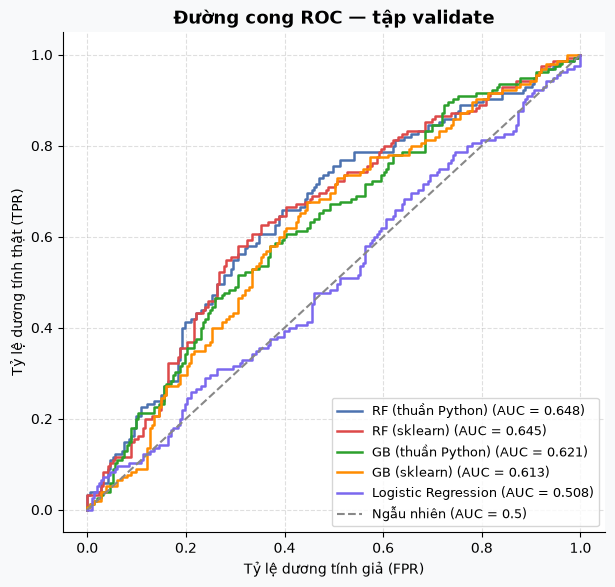

In [9]:
from utilities import plotStyle

fig, ax = plt.subplots(figsize=(7, 6.5))
fig.patch.set_facecolor(plotStyle.FIGURE_BG_COLOR)

palette = [plotStyle.POINT_COLOR, plotStyle.LINE_COLOR, plotStyle.RESIDUAL_COLOR,
           plotStyle.LOSS_COLOR, plotStyle.BAR_COLOR]

for position, (name, (vp, vs, tp, ts)) in enumerate(MODELS.items()):
    false_positive_rates, true_positive_rates, _ = \
        metricsClassification.calculate_roc_curve(validation_targets, vs)
    auc = metricsClassification.calculate_roc_auc(validation_targets, vs)
    ax.plot(false_positive_rates, true_positive_rates, linewidth=1.8,
            color=palette[position % len(palette)], label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], color=plotStyle.NEUTRAL_COLOR, linestyle='--', linewidth=1.5,
        label='Ngẫu nhiên (AUC = 0.5)')
ax.set_xlabel('Tỷ lệ dương tính giả (FPR)')
ax.set_ylabel('Tỷ lệ dương tính thật (TPR)')
ax.set_title('Đường cong ROC — tập validate', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plotStyle.apply_axes_style(ax)
plotStyle.save_figure(fig, f"{config['dataset']['label']}_05_roc_comparison.png")
plt.show()

## 6. Kết luận

Ba điều cần rút ra:

1. **Cài đặt thuần Python cho kết quả tương đương scikit-learn** trên cùng cấu
   hình — xác nhận phần lõi của dự án là đúng.
2. Chênh lệch giữa các họ mô hình **nhỏ hơn nhiều** so với chênh lệch giữa tập
   validate và tập test. Với dữ liệu tài chính, chọn mô hình nào không quan trọng
   bằng việc **kiểm định trung thực**.
3. Mọi mô hình đều cần được đọc cùng với mốc đối chứng majority. Một con số
   Accuracy đứng riêng không nói lên điều gì.